# Data Profiling and Quality Risk Analysis
**ETL (G01) — Workshop-2: Building a Reliable Batch Data Pipeline** · Section 6.3

Profiling is evidence gathering: it **describes** the data and never modifies it. Every risk found here is registered
with its evidence and the requirement it threatens (R1-R3, see `docs/requirements.md`), and feeds the quality rules (6.5).

| Source | Where it is read from |
|---|---|
| Spotify | CSV file `data/raw/spotify_dataset.csv` |
| Grammy Awards | PostgreSQL source table `grammy_source.public.grammy_awards` (not the CSV) |

Run order: start the Docker stack, run `python src/load_grammy_source.py` once, then *Run All*.

## 0. Setup

In [1]:
import re, sys, unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
from src import config

OUT = config.EVIDENCE_DIR / "profiling"
OUT.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 170)
pd.set_option("display.max_colwidth", 80)

RISKS = []   # risk register: filled along the notebook, exported at the end

def add_risk(dataset, attribute, evidence, risk, requirement):
    RISKS.append({"Dataset / Attribute": f"{dataset} / {attribute}", "Profiling Evidence": evidence,
                  "Potential Quality Risk": risk, "Related Requirement": requirement})

def pct(part, whole):
    return round(100 * part / whole, 2) if whole else 0.0

def save(df, name):
    df.to_csv(OUT / f"{name}.csv")
    return df

## 1. Load both sources (read-only)

In [2]:
spotify = pd.read_csv(config.SPOTIFY_CSV)

p = config.pg_params(config.SOURCE_DB)
engine = create_engine(URL.create("postgresql+psycopg2", username=p["user"], password=p["password"],
                                  host=p["host"], port=p["port"], database=p["dbname"]))
with engine.connect() as conn:
    grammy = pd.read_sql("SELECT * FROM public.grammy_awards ORDER BY source_row_id", conn)

print(f"Spotify (CSV)        : {spotify.shape[0]:>7,} rows x {spotify.shape[1]} columns")
print(f"Grammy  (PostgreSQL) : {grammy.shape[0]:>7,} rows x {grammy.shape[1]} columns")

Spotify (CSV)        : 114,000 rows x 21 columns
Grammy  (PostgreSQL) :   4,810 rows x 11 columns


## 2. Structure
Schema, row counts, data types and the fields each requirement needs.

In [3]:
def structure(df):
    return pd.DataFrame({"dtype": df.dtypes.astype(str), "non_null": df.notna().sum(), "n_unique": df.nunique()})

display(save(structure(spotify), "structure_spotify"))
display(save(structure(grammy), "structure_grammy"))

,dtype,non_null,n_unique
Unnamed: 0,int64,114000,114000
track_id,str,114000,89741
artists,str,113999,31437
album_name,str,113999,46589
track_name,str,113999,73608
popularity,int64,114000,101
duration_ms,int64,114000,50697
explicit,bool,114000,2
danceability,float64,114000,1174
energy,float64,114000,2083


,dtype,non_null,n_unique
source_row_id,int64,4810,4810
year,int64,4810,62
title,str,4810,62
published_at,"datetime64[us, UTC]",4810,4
updated_at,"datetime64[us, UTC]",4810,10
category,str,4810,638
nominee,str,4804,4131
artist,str,2970,1658
workers,str,2620,2366
img,str,3443,1463


In [4]:
required = {
    "R1": {"Spotify": ["artists", "popularity", "track_id"], "Grammy": ["artist"]},
    "R2": {"Spotify": ["track_genre", "danceability", "energy", "valence", "acousticness"], "Grammy": ["artist"]},
    "R3": {"Spotify": ["track_id", "popularity", "artists"], "Grammy": ["artist", "category", "year"]},
}
rows = []
for req, srcs in required.items():
    for src, cols in srcs.items():
        df = spotify if src == "Spotify" else grammy
        missing = [c for c in cols if c not in df.columns]
        rows.append({"Requirement": req, "Source": src, "Required fields": ", ".join(cols),
                     "All present": not missing, "Missing": ", ".join(missing)})
req_fields = save(pd.DataFrame(rows).set_index("Requirement"), "required_fields")
display(req_fields)

if "Unnamed: 0" in spotify.columns:
    is_index = (spotify["Unnamed: 0"] == np.arange(len(spotify))).all()
    print("Spotify 'Unnamed: 0' equals the row index:", is_index)
    add_risk("Spotify", "Unnamed: 0", f"Unnamed integer column equal to row index: {is_index}",
             "Artifact of a previous export; not a business attribute and could be mistaken for a key.", "R1-R3")

,Source,Required fields,All present,Missing
Requirement,,,,
R1,Spotify,"artists, popularity, track_id",True,
R1,Grammy,artist,True,
R2,Spotify,"track_genre, danceability, energy, valence, acousticness",True,
R2,Grammy,artist,True,
R3,Spotify,"track_id, popularity, artists",True,
R3,Grammy,"artist, category, year",True,


Spotify 'Unnamed: 0' equals the row index: True


## 3. Completeness

In [5]:
def completeness(df):
    m = df.isna().sum()
    out = pd.DataFrame({"missing": m, "missing_pct": (100 * m / len(df)).round(2)})
    return out[out["missing"] > 0]

comp_sp = save(completeness(spotify), "completeness_spotify")
comp_gr = save(completeness(grammy), "completeness_grammy")
display(comp_sp); display(comp_gr)

for col in comp_sp.index:
    add_risk("Spotify", col, f"{int(comp_sp.loc[col,'missing'])} missing ({comp_sp.loc[col,'missing_pct']}%)",
             "A track with no artist cannot be linked to Grammy data; negligible volume." if col == "artists"
             else "Incomplete descriptive attribute; low impact.", "R1-R3" if col == "artists" else "Informational")
n_art = int(comp_gr.loc["artist", "missing"]); p_art = comp_gr.loc["artist", "missing_pct"]
add_risk("Grammy", "artist", f"{n_art:,} missing ({p_art}%)",
         "Rows without artist (e.g. technical or classical categories) cannot be integrated with Spotify; "
         "KPIs cover only the awards that have an artist.", "R1, R2, R3")
if "nominee" in comp_gr.index:
    add_risk("Grammy", "nominee", f"{int(comp_gr.loc['nominee','missing'])} missing ({comp_gr.loc['nominee','missing_pct']}%)",
             "Awarded work not identifiable for these rows; low volume.", "Informational")

,missing,missing_pct
artists,1,0.0
album_name,1,0.0
track_name,1,0.0


,missing,missing_pct
nominee,6,0.12
artist,1840,38.25
workers,2190,45.53
img,1367,28.42


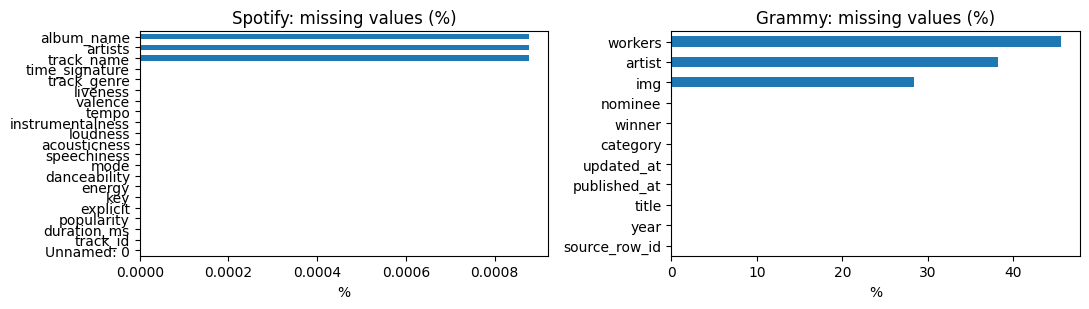

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, df, name in [(axes[0], spotify, "Spotify"), (axes[1], grammy, "Grammy")]:
    (100 * df.isna().mean()).sort_values().plot.barh(ax=ax, color="#1f77b4")
    ax.set_title(f"{name}: missing values (%)"); ax.set_xlabel("%")
plt.tight_layout(); plt.savefig(OUT / "fig_missing.png", dpi=130); plt.show()

## 4. Uniqueness and duplication
Candidate keys, duplicate patterns, and whether repeated values are expected at the source grain.

In [7]:
sp = spotify.drop(columns=["Unnamed: 0"], errors="ignore")
n = len(sp)
extra_track_id   = int(sp.duplicated("track_id").sum())
extra_track_genre = int(sp.duplicated(["track_id", "track_genre"]).sum())
extra_full       = int(sp.duplicated().sum())
tracks_unique    = sp["track_id"].nunique()

pop_by_track = sp.groupby("track_id")["popularity"].nunique()
tracks_multi_pop = int((pop_by_track > 1).sum())
multi_genre = sp.groupby("track_id")["track_genre"].nunique()
# same song under different track_id (re-releases / compilations)
song_key = sp.dropna(subset=["track_name", "artists"]).assign(
    song=lambda d: d["track_name"].str.casefold().str.strip() + "|" + d["artists"].str.casefold().str.strip())
song_multi_id = int((song_key.groupby("song")["track_id"].nunique() > 1).sum())

uniq_sp = pd.DataFrame({
    "metric": ["rows", "distinct track_id", "extra rows repeating a track_id",
               "extra rows repeating (track_id, track_genre)", "fully duplicated rows",
               "track_id with >1 distinct popularity value", "track_id appearing in >1 genre",
               "songs (name+artists) with >1 track_id"],
    "value": [n, tracks_unique, extra_track_id, extra_track_genre, extra_full,
              tracks_multi_pop, int((multi_genre > 1).sum()), song_multi_id]}).set_index("metric")
display(save(uniq_sp, "uniqueness_spotify"))

add_risk("Spotify", "track_id", f"{extra_track_id:,} rows repeat a track_id ({pct(extra_track_id, n)}% of rows); "
         f"{int((multi_genre>1).sum()):,} tracks appear in more than one genre; "
         f"(track_id, track_genre) repeats: {extra_track_genre}; fully duplicated rows: {extra_full}",
         "Natural grain is track x genre, and exact duplicate rows exist. Counting or averaging at row level over-weights "
         "multi-genre tracks and duplicates, and inflates track counts.", "R1, R2, R3")
add_risk("Spotify", "popularity", f"{tracks_multi_pop:,} tracks carry different popularity values across their genre rows",
         "No single popularity per track; the aggregation rule must be explicit (e.g. max or mean per track).", "R1, R3")
add_risk("Spotify", "track_name + artists", f"{song_multi_id:,} songs have more than one track_id",
         "Same song released under several ids (albums, re-releases) can double-count a song.", "R1, R3")

,value
metric,
rows,114000
distinct track_id,89741
extra rows repeating a track_id,24259
"extra rows repeating (track_id, track_genre)",450
fully duplicated rows,450
track_id with >1 distinct popularity value,720
track_id appearing in >1 genre,16299
songs (name+artists) with >1 track_id,4747


In [8]:
g = grammy.drop(columns=["source_row_id"])
biz_key = ["year", "category", "nominee", "artist"]
uniq_gr = pd.DataFrame({
    "metric": ["rows", "fully duplicated rows (excluding source_row_id)",
               f"rows repeating {biz_key}", "distinct ceremonies (title)"],
    "value": [len(g), int(g.duplicated().sum()), int(g.duplicated(biz_key).sum()), g["title"].nunique()]}).set_index("metric")
display(save(uniq_gr, "uniqueness_grammy"))

awards_per_artist = grammy["artist"].value_counts()
print("Rows per artist (Grammy): max", awards_per_artist.max(), "| artists with >1 row:", int((awards_per_artist > 1).sum()))
display(awards_per_artist.head(10).to_frame("awards"))
add_risk("Grammy", "(year, category, nominee, artist)", f"{int(g.duplicated(biz_key).sum())} repeated business keys; "
         f"{int(g.duplicated().sum())} fully duplicated rows",
         "No natural key in the source (a technical source_row_id is added). Repeated values per artist are expected "
         "(one row per award), so artist is not a key.", "R3")

,value
metric,
rows,4810
fully duplicated rows (excluding source_row_id),0
"rows repeating ['year', 'category', 'nominee', 'artist']",0
distinct ceremonies (title),62


Rows per artist (Grammy): max 66 | artists with >1 row: 487


,awards
artist,
(Various Artists),66
U2,18
Aretha Franklin,16
Beyoncé,13
Bruce Springsteen,13
Stevie Wonder,13
Ella Fitzgerald,13
Dixie Chicks,12
Tony Bennett,12


## 5. Categorical content

In [9]:
def variants(s):
    s = s.dropna()
    raw = s.nunique()
    normalized = s.str.strip().str.casefold().str.replace(r"\s+", " ", regex=True).nunique()
    padded = int((s != s.str.strip()).sum())
    return raw, normalized, padded

rows = []
for name, s in [("Spotify.track_genre", spotify["track_genre"]), ("Spotify.album_name", spotify["album_name"]),
                ("Grammy.category", grammy["category"]), ("Grammy.artist", grammy["artist"]),
                ("Grammy.nominee", grammy["nominee"]), ("Grammy.title", grammy["title"])]:
    raw, norm_n, padded = variants(s)
    rows.append({"attribute": name, "distinct": raw, "distinct_after_trim_casefold": norm_n,
                 "labels_that_collapse": raw - norm_n, "values_with_extra_spaces": padded})
cat_var = save(pd.DataFrame(rows).set_index("attribute"), "categorical_variants")
display(cat_var)

,distinct,distinct_after_trim_casefold,labels_that_collapse,values_with_extra_spaces
attribute,,,,
Spotify.track_genre,114,114,0,0
Spotify.album_name,46589,46155,434,0
Grammy.category,638,629,9,0
Grammy.artist,1658,1656,2,0
Grammy.nominee,4131,4130,1,0
Grammy.title,62,62,0,0


In [10]:
genre_counts = spotify.groupby("track_genre")["track_id"].nunique().sort_values(ascending=False)
print("Spotify genres:", len(genre_counts), "| tracks per genre: min", genre_counts.min(),
      "median", int(genre_counts.median()), "max", genre_counts.max())
display(genre_counts.head(8).to_frame("distinct tracks").T)
display(genre_counts.tail(5).to_frame("distinct tracks").T)

domains = pd.DataFrame({
    "explicit": spotify["explicit"].value_counts(dropna=False),
    "mode": spotify["mode"].value_counts(dropna=False),
}).fillna(0).astype(int)
display(domains)
print("key values       :", sorted(int(v) for v in spotify["key"].unique()))
print("time_signature   :", sorted(int(v) for v in spotify["time_signature"].unique()))

winner_vals = grammy["winner"].value_counts(dropna=False)
print("\nGrammy winner values:\n", winner_vals.to_string())
cat_n = grammy["category"].nunique()
cat_top = grammy["category"].value_counts()
print(f"\nGrammy categories: {cat_n}; categories with a single row: {int((cat_top==1).sum())}")
display(cat_top.head(8).to_frame("rows").T)

add_risk("Grammy", "winner", f"Values: {winner_vals.to_dict()}",
         "Constant attribute: the table only holds awarded entries. No nominee-only rows, so win rate and "
         "nomination-based KPIs are impossible; measures must be 'awards'.", "R3 (and scope of R1)")
add_risk("Grammy", "category", f"{cat_n} distinct categories, {int((cat_top==1).sum())} used once; "
         f"labels collapsing after trim/casefold: {int(cat_var.loc['Grammy.category','labels_that_collapse'])}",
         "Very high cardinality and changing category names over six decades: a dimension needs a clear key and "
         "no grouping by category family can be assumed.", "R3")
add_risk("Spotify", "track_genre", f"{len(genre_counts)} genres; tracks per genre from {genre_counts.min()} to {genre_counts.max()}; "
         f"labels collapsing: {int(cat_var.loc['Spotify.track_genre','labels_that_collapse'])}",
         "Genre is assigned per row, not per track: comparisons across genres depend on the track x genre grain.", "R2")

Spotify genres: 114 | tracks per genre: min 904 median 999 max 1000


track_genre,acoustic,british,electronic,emo,funk,garage,disco,country
distinct tracks,1000,1000,1000,1000,1000,1000,1000,1000


track_genre,honky-tonk,dance,german,classical,romance
distinct tracks,981,965,963,933,904


,explicit,mode
False,104253,41319
0,104253,41319
True,9747,72681
1,9747,72681


key values       : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
time_signature   : [0, 1, 3, 4, 5]

Grammy winner values:
 winner
True    4810

Grammy categories: 638; categories with a single row: 224


category,Song Of The Year,Record Of The Year,Album Of The Year,Best Opera Recording,Best Album Notes,Best Country Song,Best Instrumental Composition,Best New Artist
rows,70,69,66,64,63,55,55,51


In [11]:
sp_art = spotify.dropna(subset=["artists"])
multi = sp_art["artists"].str.contains(";", regex=False)
n_artists_per_track = sp_art["artists"].str.count(";") + 1
print(f"Spotify rows with several artists ';': {int(multi.sum()):,} ({pct(multi.sum(), len(sp_art))}%); max artists in a row: {int(n_artists_per_track.max())}")
add_risk("Spotify", "artists", f"{int(multi.sum()):,} rows ({pct(multi.sum(), len(sp_art))}%) list several artists separated by ';'",
         "Multi-valued attribute: integration needs one row per (track, artist); otherwise collaborations never match.", "R1, R2, R3")

sep = r"\s(?:&|and|feat\.?|featuring|with|vs\.?|x)\s|,|;|/"
gr_art = grammy.dropna(subset=["artist"])
gr_multi = gr_art["artist"].str.contains(sep, case=False, regex=True)
print(f"Grammy artist values that look like several artists: {int(gr_multi.sum()):,} ({pct(gr_multi.sum(), len(gr_art))}%)")
display(gr_art.loc[gr_multi, "artist"].drop_duplicates().head(8).to_frame())

Spotify rows with several artists ';': 30,075 (26.38%); max artists in a row: 38
Grammy artist values that look like several artists: 563 (18.96%)


,artist
5,Lil Nas X Featuring Billy Ray Cyrus
7,Post Malone & Swae Lee
38,Ariana Grande & Social House
41,Shawn Mendes & Camila Cabello
42,Elvis Costello & The Imposters
54,Meduza Featuring Goodboys
56,"Skrillex, Boys Noize & Ty Dolla $ign"
61,Tycho Featuring Saint Sinner


## 6. Numerical content

In [12]:
num_cols = spotify.select_dtypes("number").columns.drop("Unnamed: 0", errors="ignore")
display(save(spotify[num_cols].describe().T.round(3), "numeric_spotify"))

,count,mean,std,min,25%,50%,75%,max
popularity,114000.0,33.239,22.305,0.000,17.000,35.000,50.000,100.000
duration_ms,114000.0,228029.153,107297.713,0.000,174066.000,212906.000,261506.000,5237295.000
danceability,114000.0,0.567,0.174,0.000,0.456,0.580,0.695,0.985
energy,114000.0,0.641,0.252,0.000,0.472,0.685,0.854,1.000
key,114000.0,5.309,3.560,0.000,2.000,5.000,8.000,11.000
loudness,114000.0,-8.259,5.029,-49.531,-10.013,-7.004,-5.003,4.532
mode,114000.0,0.638,0.481,0.000,0.000,1.000,1.000,1.000
speechiness,114000.0,0.085,0.106,0.000,0.036,0.049,0.084,0.965
acousticness,114000.0,0.315,0.333,0.000,0.017,0.169,0.598,0.996
instrumentalness,114000.0,0.156,0.310,0.000,0.000,0.000,0.049,1.000


,rows,pct
popularity outside 0-100,0,0.00
popularity == 0,16020,14.05
duration_ms <= 0,1,0.00
duration_ms > 20 min,81,0.07
tempo == 0,157,0.14
time_signature outside 3-7,1136,1.00
loudness > 0 dB,90,0.08
key outside 0-11,0,0.00
"mode not in {0,1}",0,0.00
"any audio feature outside [0,1]",0,0.00


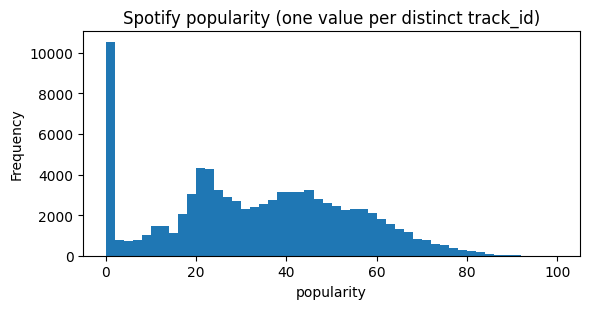

In [13]:
unit_cols = ["danceability", "energy", "speechiness", "acousticness", "instrumentalness", "liveness", "valence"]
checks = {
    "popularity outside 0-100": ~spotify["popularity"].between(0, 100),
    "popularity == 0": spotify["popularity"] == 0,
    "duration_ms <= 0": spotify["duration_ms"] <= 0,
    "duration_ms > 20 min": spotify["duration_ms"] > 20 * 60 * 1000,
    "tempo == 0": spotify["tempo"] == 0,
    "time_signature outside 3-7": ~spotify["time_signature"].between(3, 7),
    "loudness > 0 dB": spotify["loudness"] > 0,
    "key outside 0-11": ~spotify["key"].between(0, 11),
    "mode not in {0,1}": ~spotify["mode"].isin([0, 1]),
    "any audio feature outside [0,1]": ~spotify[unit_cols].apply(lambda s: s.between(0, 1)).all(axis=1),
}
num_checks = pd.DataFrame({"rows": {k: int(v.sum()) for k, v in checks.items()}})
num_checks["pct"] = (100 * num_checks["rows"] / len(spotify)).round(2)
display(save(num_checks, "numeric_domain_checks"))

pop0, ts_bad, tempo0 = int(checks["popularity == 0"].sum()), int(checks["time_signature outside 3-7"].sum()), int(checks["tempo == 0"].sum())
add_risk("Spotify", "popularity", f"Range {spotify['popularity'].min()}-{spotify['popularity'].max()}; {pop0:,} rows ({pct(pop0, len(spotify))}%) equal 0",
         "A 0 may mean 'no listening data' rather than 'unpopular'; it would drag down averages in R1 and R3.", "R1, R3")
add_risk("Spotify", "tempo / time_signature", f"tempo == 0 in {tempo0} rows; time_signature outside 3-7 in {ts_bad} rows",
         "Placeholder values for tracks the audio analysis could not process; they distort audio-profile averages.", "R2")
add_risk("Spotify", "audio features (danceability...valence)", f"Rows with any feature outside [0,1]: {int(checks['any audio feature outside [0,1]'].sum())}",
         "Features are defined on [0,1]; values outside would break comparisons.", "R2")
dur = spotify["duration_ms"]
add_risk("Spotify", "duration_ms", f"min {dur.min():,} ms, max {dur.max():,} ms ({dur.max()/60000:.0f} min); > 20 min in {int(checks['duration_ms > 20 min'].sum())} rows",
         "Extreme durations (podcasts, ambient or live sets) are not typical songs.", "Informational")

fig, ax = plt.subplots(figsize=(6, 3.2))
spotify.drop_duplicates("track_id")["popularity"].plot.hist(bins=50, ax=ax, color="#1f77b4")
ax.set_title("Spotify popularity (one value per distinct track_id)"); ax.set_xlabel("popularity")
plt.tight_layout(); plt.savefig(OUT / "fig_popularity.png", dpi=130); plt.show()

## 7. Temporal content

Grammy year coverage: 1958-2019 | distinct years: 62 | missing years in range: []
Rows where the year in 'title' differs from 'year': 0 | years with more than one ceremony title: 0
published_at: unparseable = 0, distinct values = 4, range 2017-11-28 -> 2020-05-19
updated_at: unparseable = 0, distinct values = 10, range 2017-11-28 -> 2020-09-01


decade,1950,1960,1970,1980,1990,2000,2010
awards,63,433,487,684,866,1067,1210


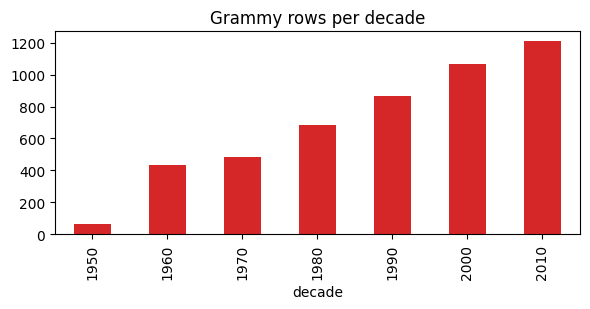

Spotify temporal columns: none


In [14]:
years = grammy["year"]
all_years = set(range(int(years.min()), int(years.max()) + 1))
gap_years = sorted(all_years - set(years.unique()))
print(f"Grammy year coverage: {years.min()}-{years.max()} | distinct years: {years.nunique()} | missing years in range: {gap_years}")

title_year = grammy["title"].str.extract(r"\((\d{4})\)")[0].astype(float)
mismatch = int((title_year != grammy["year"]).sum())
ceremony = grammy.groupby("year")["title"].nunique()
print(f"Rows where the year in 'title' differs from 'year': {mismatch} | years with more than one ceremony title: {int((ceremony>1).sum())}")

for c in ["published_at", "updated_at"]:
    parsed = pd.to_datetime(grammy[c], errors="coerce", utc=True)
    print(f"{c}: unparseable = {int(parsed.isna().sum())}, distinct values = {grammy[c].nunique()}, range {parsed.min().date()} -> {parsed.max().date()}")

per_decade = grammy.assign(decade=(grammy["year"] // 10) * 10).groupby("decade").size()
display(save(per_decade.to_frame("awards"), "grammy_awards_per_decade").T)
fig, ax = plt.subplots(figsize=(6, 3.2))
per_decade.plot.bar(ax=ax, color="#d62728"); ax.set_title("Grammy rows per decade"); ax.set_xlabel("decade")
plt.tight_layout(); plt.savefig(OUT / "fig_grammy_decade.png", dpi=130); plt.show()
print("Spotify temporal columns:", [c for c in spotify.columns if re.search(r"date|year|release", c, re.I)] or "none")

add_risk("Grammy", "year / title", f"Coverage {years.min()}-{years.max()}, missing years: {gap_years or 'none'}; year vs title mismatches: {mismatch}",
         "Year is reliable for the Grammy side, but Grammy stops in 2019 while Spotify reflects its current catalog.", "R3")
add_risk("Grammy", "published_at / updated_at", f"{grammy['published_at'].nunique()} and {grammy['updated_at'].nunique()} distinct values for {len(grammy):,} rows",
         "They are load/publication timestamps of the website, not event dates; must not be used as award dates.", "Informational")
add_risk("Spotify vs Grammy", "time", "Spotify has no release or date attribute",
         "Tracks cannot be aligned with the year of an award: relationships are by artist, not by time. Any 'before/after award' "
         "claim is outside what the data can support.", "R1, R2, R3")

## 8. Cross-source consistency
Compatibility of the **artist** attribute, the planned integration key (assumption A1). The normalization below
(accent removal, case folding, punctuation removal) is a *measurement* for profiling; the transformation rule is decided in 6.8.

,value
metric,
Grammy distinct artist keys,1643.00
Spotify distinct artist keys,29742.00
Matching keys,540.00
% Grammy artist keys found in Spotify,32.87
% Grammy rows (with artist) matched,46.80
% Grammy rows overall matched,28.90
Spotify distinct tracks,89741.00
Spotify tracks by a Grammy artist,6801.00
% Spotify tracks linked to a Grammy artist,7.58


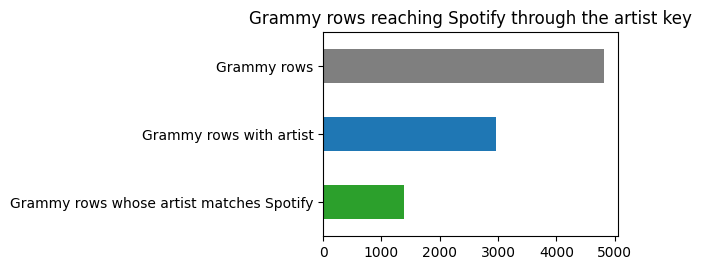

In [15]:
def norm(s):
    if pd.isna(s):
        return None
    s = unicodedata.normalize("NFKD", str(s))
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    return re.sub(r"[\W_]+", "", s.casefold()) or None

sp_exp = (spotify.dropna(subset=["artists"])[["track_id", "track_genre", "artists"]]
          .assign(artist_raw=lambda d: d["artists"].str.split(";")).explode("artist_raw"))
sp_exp["artist_raw"] = sp_exp["artist_raw"].str.strip()
cache = {a: norm(a) for a in sp_exp["artist_raw"].unique()}
sp_exp["artist_key"] = sp_exp["artist_raw"].map(cache)

gr_art = grammy.dropna(subset=["artist"]).copy()
gr_art["artist_key"] = gr_art["artist"].map({a: norm(a) for a in gr_art["artist"].unique()})

sp_keys, gr_keys = set(sp_exp["artist_key"].dropna()), set(gr_art["artist_key"].dropna())
matched = sp_keys & gr_keys
rows_matched = gr_art["artist_key"].isin(matched)
tracks_total = spotify["track_id"].nunique()
tracks_linked = sp_exp.loc[sp_exp["artist_key"].isin(matched), "track_id"].nunique()

funnel = pd.Series({
    "Grammy rows": len(grammy),
    "Grammy rows with artist": len(gr_art),
    "Grammy rows whose artist matches Spotify": int(rows_matched.sum()),
}, name="rows")
summary = pd.DataFrame({
    "metric": ["Grammy distinct artist keys", "Spotify distinct artist keys", "Matching keys",
               "% Grammy artist keys found in Spotify", "% Grammy rows (with artist) matched",
               "% Grammy rows overall matched", "Spotify distinct tracks", "Spotify tracks by a Grammy artist",
               "% Spotify tracks linked to a Grammy artist"],
    "value": [len(gr_keys), len(sp_keys), len(matched), pct(len(matched), len(gr_keys)),
              pct(rows_matched.sum(), len(gr_art)), pct(rows_matched.sum(), len(grammy)), tracks_total,
              tracks_linked, pct(tracks_linked, tracks_total)]}).set_index("metric")
display(save(summary, "cross_source_match"))

fig, ax = plt.subplots(figsize=(6.5, 2.8))
funnel.plot.barh(ax=ax, color=["#7f7f7f", "#1f77b4", "#2ca02c"]); ax.invert_yaxis()
ax.set_title("Grammy rows reaching Spotify through the artist key")
plt.tight_layout(); plt.savefig(OUT / "fig_match_funnel.png", dpi=130); plt.show()

In [16]:
# Does the collaboration format of the Grammy artist hurt matching?
sep = r"\s(?:&|and|feat\.?|featuring|with|vs\.?|x)\s|,|;|/"
gr_art["looks_multi"] = gr_art["artist"].str.contains(sep, case=False, regex=True)
gr_art["matched"] = rows_matched.values
by_format = gr_art.groupby("looks_multi")["matched"].agg(rows="size", matched="sum")
by_format["match_pct"] = (100 * by_format["matched"] / by_format["rows"]).round(2)
by_format.index = by_format.index.map({False: "single artist", True: "looks like several artists"})
display(save(by_format, "match_by_artist_format"))

# Cardinality of the relationship through the key
tracks_per_key = sp_exp[sp_exp["artist_key"].isin(matched)].groupby("artist_key")["track_id"].nunique()
awards_per_key = gr_art[gr_art["artist_key"].isin(matched)].groupby("artist_key").size()
card = pd.DataFrame({"tracks per matched artist": tracks_per_key.describe(), "awards per matched artist": awards_per_key.describe()}).round(1)
display(save(card, "cardinality_by_key"))

# Spelling variants sharing one key (possible homonyms or inconsistent writing)
sp_var = sp_exp.dropna(subset=["artist_key"]).groupby("artist_key")["artist_raw"].nunique()
gr_var = gr_art.groupby("artist_key")["artist"].nunique()
print("Spotify keys with >1 written form:", int((sp_var > 1).sum()), "| Grammy keys with >1 written form:", int((gr_var > 1).sum()))

fmt_multi = by_format.loc["looks like several artists"]
add_risk("Spotify vs Grammy", "artist (integration key)",
         f"{len(matched):,} of {len(gr_keys):,} Grammy artist keys ({pct(len(matched), len(gr_keys))}%) found in Spotify; "
         f"{tracks_linked:,} of {tracks_total:,} tracks ({pct(tracks_linked, tracks_total)}%) linked",
         "There is no shared id: matching by name loses artists written differently and may join homonyms. "
         "Only a minority of Grammy artists exist in the Spotify sample, so Grammy KPIs describe the overlap, not all Grammy history.", "R1, R2, R3")
add_risk("Grammy", "artist (collaboration format)",
         f"{int(fmt_multi['rows'])} rows look like several artists; {fmt_multi['match_pct']}% of them match vs "
         f"{by_format.loc['single artist','match_pct']}% for single artists",
         "Grammy writes collaborations in one string (e.g. 'A & B'); matching the whole string misses them.", "R1, R2, R3")
add_risk("Spotify vs Grammy", "artist -> tracks / awards",
         f"Matched artists have up to {int(tracks_per_key.max())} tracks and {int(awards_per_key.max())} awards",
         "Many-to-many through the key: summing awards after joining to tracks multiplies them (fan-out). "
         "Facts must be built at a grain that avoids double counting.", "R1, R3")

# Generic credits and parenthesized values in the Grammy artist field
GENERIC_CREDITS = {"variousartists", "originalcast", "originalbroadwaycast"}   # credits that do not identify an act
gr_art["is_generic"] = gr_art["artist_key"].isin(GENERIC_CREDITS)
generic_values = gr_art.loc[gr_art["is_generic"], "artist"].value_counts()
display(generic_values.to_frame("rows"))
paren = gr_art["artist"].str.match(r"^\(.*\)$")
paren_distinct = gr_art.loc[paren, "artist"].nunique()
paren_generic = gr_art.loc[paren & gr_art["is_generic"], "artist"].nunique()
display(gr_art.loc[paren & ~gr_art["is_generic"], "artist"].drop_duplicates().head(8).to_frame("parenthesized, not generic"))
generic_in_spotify = bool(GENERIC_CREDITS & sp_keys)
add_risk("Grammy", "artist (generic credit)", f"{int(gr_art['is_generic'].sum())} rows ({pct(gr_art['is_generic'].sum(), len(gr_art))}% of rows with artist) credit "
         f"{list(generic_values.index)}; the same key exists in Spotify: {generic_in_spotify}",
         "Not an identifiable act: it would become the 'most awarded artist' in R3 and could join unrelated Spotify rows.", "R3")
add_risk("Grammy", "artist (parentheses)", f"{paren_distinct} distinct values wrapped in parentheses; only {paren_generic} of them are generic credits "
         f"(the rest are named acts such as {list(gr_art.loc[paren & ~gr_art['is_generic'], 'artist'].drop_duplicates().head(3))})",
         "Parentheses are a formatting convention, not a placeholder marker. The matching key already ignores them, "
         "but the display name must strip them and they must not trigger placeholder treatment.", "R3")

,rows,matched,match_pct
looks_multi,,,
single artist,2407,1350,56.09
looks like several artists,563,40,7.10


,tracks per matched artist,awards per matched artist
count,540.0,540.0
mean,13.4,2.6
std,24.9,3.6
min,1.0,1.0
25%,2.0,1.0
50%,5.0,1.0
75%,14.0,3.0
max,332.0,66.0


Spotify keys with >1 written form: 114 | Grammy keys with >1 written form: 15


,rows
artist,
(Various Artists),66
(Original Broadway Cast),1
(Original Cast),1
Original Cast,1


,"parenthesized, not generic"
430,(Miles Davis)
591,(Depeche Mode)
592,(Jane Ira Bloom)
1209,(The Doors)
1512,(The Beatles)
1970,(Sam Cooke)
2143,(Sesame Street Characters)
2276,(John Lennon)


## 9. Quality risk register

In [17]:
risk_table = pd.DataFrame(RISKS)
risk_table.insert(0, "Risk ID", [f"RK{i:02d}" for i in range(1, len(risk_table) + 1)])
risk_table.to_csv(OUT / "risk_register.csv", index=False)
with open(OUT / "risk_register.md", "w", encoding="utf-8") as f:
    f.write("| " + " | ".join(risk_table.columns) + " |\n|" + "---|" * len(risk_table.columns) + "\n")
    for _, r in risk_table.iterrows():
        f.write("| " + " | ".join(str(v).replace("|", "/") for v in r) + " |\n")
print(f"{len(risk_table)} risks registered. Evidence saved in: {OUT}")
display(risk_table.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "pre-wrap"}))

26 risks registered. Evidence saved in: /tmp/t2/docs/evidence/profiling


Risk ID,Dataset / Attribute,Profiling Evidence,Potential Quality Risk,Related Requirement
RK01,Spotify / Unnamed: 0,Unnamed integer column equal to row index: True,Artifact of a previous export; not a business attribute and could be mistaken for a key.,R1-R3
RK02,Spotify / artists,1 missing (0.0%),A track with no artist cannot be linked to Grammy data; negligible volume.,R1-R3
RK03,Spotify / album_name,1 missing (0.0%),Incomplete descriptive attribute; low impact.,Informational
RK04,Spotify / track_name,1 missing (0.0%),Incomplete descriptive attribute; low impact.,Informational
RK05,Grammy / artist,"1,840 missing (38.25%)",Rows without artist (e.g. technical or classical categories) cannot be integrated with Spotify; KPIs cover only the awards that have an artist.,"R1, R2, R3"
RK06,Grammy / nominee,6 missing (0.12%),Awarded work not identifiable for these rows; low volume.,Informational
RK07,Spotify / track_id,"24,259 rows repeat a track_id (21.28% of rows); 16,299 tracks appear in more than one genre; (track_id, track_genre) repeats: 450; fully duplicated rows: 450","Natural grain is track x genre, and exact duplicate rows exist. Counting or averaging at row level over-weights multi-genre tracks and duplicates, and inflates track counts.","R1, R2, R3"
RK08,Spotify / popularity,720 tracks carry different popularity values across their genre rows,No single popularity per track; the aggregation rule must be explicit (e.g. max or mean per track).,"R1, R3"
RK09,Spotify / track_name + artists,"4,747 songs have more than one track_id","Same song released under several ids (albums, re-releases) can double-count a song.","R1, R3"
RK10,"Grammy / (year, category, nominee, artist)",0 repeated business keys; 0 fully duplicated rows,"No natural key in the source (a technical source_row_id is added). Repeated values per artist are expected (one row per award), so artist is not a key.",R3


### Next step
Each risk above is converted in 6.5 into a quality rule (dimension, metric, threshold, severity) and a Great Expectations
expectation. Profiling evidence was saved under `docs/evidence/profiling/` so the rules can cite it.